# Run cells from AllenDB

In [1]:
import os, sys, json
import matplotlib.pyplot as plt
import numpy as np

# Import SCP modules
from modules import download_cell
from modules import build_cell
from modules import run_sim

# Import ACT modules
act_path = "../../mods/ACT"
if os.path.isdir(act_path):
    sys.path.append(act_path)
else:
    !pip install --upgrade pip2 > /dev/null 2>&1
    !pip install --quiet allensdk neuron > /dev/null 2>&1
    !git clone https://github.com/V-Marco/ACT.git
    sys.path.append('ACT')
from act.passive import ACTPassiveModule

--No graphics will be displayed.


# Download Cell

### Set Parameters

In [2]:
cell_name = 'PV' #SST, SST_0, PV, PN

if os.path.isdir(f"cells/{cell_name}"): os.chdir(f"cells/{cell_name}") #else: create?

# http://celltypes.brain-map.org/mouse/experiment/electrophysiology/'specimen_id'
spec_ids = {'SST':476686112, 'SST': 485466109, 'PV': 484635029}
specimen_id = spec_ids[cell_name] #SST 476686112, SST 485466109, PV 484635029, 571709783
model_type = 'perisomatic' #or 'all active'

tunes_dir = 'tunes'
model_dir = 'seg_tuned' #f'OriginalFromAllenDB/{specimen_id}_{model_type}' # or None=tunes_dir

In [ ]:
from pathlib import Path
import json

cfg_path = Path(tunes_dir) / model_dir / "cell_configs" / "sim_config.json"
if not cfg_path.is_file():
    cfg_path = Path(tunes_dir) / model_dir / "sim_config.json"
if not cfg_path.is_file():
    cfg_path = Path(f"cells/{cell_name}") / tunes_dir / model_dir / "cell_configs" / "sim_config.json"
if not cfg_path.is_file():
    cfg_path = Path(f"cells/{cell_name}") / tunes_dir / model_dir / "sim_config.json"
if cfg_path.is_file():
    sim_cfg_preview = json.loads(cfg_path.read_text())
    if 'specimen_id' in sim_cfg_preview:
        specimen_id = sim_cfg_preview['specimen_id']
    if 'model_type' in sim_cfg_preview:
        model_type = sim_cfg_preview['model_type']
    if 'soma_diam_multiplier' in sim_cfg_preview:
        soma_diam_multiplier = sim_cfg_preview['soma_diam_multiplier']
    # Refresh model_dir if it uses OriginalFromAllenDB/<specimen>_<model>
    if isinstance(model_dir, str) and model_dir.startswith('OriginalFromAllenDB/'):
        model_dir = f"OriginalFromAllenDB/{specimen_id}_{model_type}"


### Download Cell (if not already downloaded)

In [3]:
# (Optional) list available bundles for a specimen
download_cell.list_ADB_models(specimen_id)                             # all
download_cell.list_ADB_models(specimen_id, filter_type=model_type)  # filtered

# Download a bundle
cell_info = download_cell.download_ADB_cell(
    specimen_id=specimen_id,
    model_type=model_type,          # or "all active"
    tunes_dir=tunes_dir,    # base dir
    cache_stimulus=False,              # skip big NWB
    subdir=model_dir,          # None ='tunes_dir/', else ='tunes_dir'/'model_dir/'
    match="contains",                  # name matching behavior
    quiet=False,
)
cell_info["model_id"], cell_info["model_name"], cell_info["tunes_dir"]

# List the files you just pulled
len(cell_info["files"]), cell_info["files"][:5]

Models for specimen_id=484635029:
  485602029  Biophysical - perisomatic_Pvalb-IRES-Cre;Ai14-201791.05.01.01
  496538965  Biophysical - all active_Pvalb-IRES-Cre;Ai14-201791.05.01.01
Models for specimen_id=484635029:
  485602029  Biophysical - perisomatic_Pvalb-IRES-Cre;Ai14-201791.05.01.01
[download_ADB_cell] Found existing cache at: tunes/seg_tuned — skipping download.


(146,
 ['tunes/seg_tuned/484635029_fit.json',
  'tunes/seg_tuned/Pvalb-IRES-Cre_Ai14-201791.05.01.01_496079599_m.swc',
  'tunes/seg_tuned/Pvalb-IRES-Cre_Ai14-201791.05.01.01_496079599_marker_m.swc',
  'tunes/seg_tuned/manifest.json',
  'tunes/seg_tuned/modfiles/AMPA_NMDA_STP.mod'])

### Compile Modfiles

In [4]:
os.chdir(f'{tunes_dir}/{model_dir}')

# update_modfiles = None # or path/link to modfiles TODO
# if update_modfiles is not None:
#     !git clone update_modfiles

# if already compiled then lets delete the folder and force a recompile
if os.path.isdir('modfiles/x86_64'):
    os.system("rm -rf modfiles/x86_64")
# compile the mod files
if not os.path.isdir("modfiles/x86_64"):
    # !nrnivmodl modfiles > /dev/null 2>&1
    os.chdir('modfiles')
    os.system("nrnivmodl")
    os.chdir("..")


from neuron import h
h.load_file("stdrun.hoc")  # Required to use h.run()
h.nrn_load_dll("modfiles/x86_64/.libs/libnrnmech.so")

/home/hrbncv/PV-SST/single_cells/cells/PV/tunes/seg_tuned/modfiles
Mod files: "./AMPA_NMDA_STP.mod" "./CaDynamics.mod" "./Ca_HVA.mod" "./Ca_LVA.mod" "./GABA_A.mod" "./Ih.mod" "./Im.mod" "./Im_v2.mod" "./Kd.mod" "./K_P.mod" "./K_T.mod" "./Kv2like.mod" "./Kv3_1.mod" "./Nap.mod" "./NaTa.mod" "./NaTs.mod" "./NaV.mod" "./SK.mod" "./vecstim.mod"

Creating 'x86_64' directory for .o files.



/home/hrbncv/miniconda3/envs/BMTK/bin/nrnivmodl:10: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import working_set
Translating AMPA_NMDA_STP.mod into /home/hrbncv/PV-SST/single_cells/cells/PV/tunes/seg_tuned/modfiles/x86_64/AMPA_NMDA_STP.c
Translating Ca_HVA.mod into /home/hrbncv/PV-SST/single_cells/cells/PV/tunes/seg_tuned/modfiles/x86_64/Ca_HVA.c
Translating CaDynamics.mod into /home/hrbncv/PV-SST/single_cells/cells/PV/tunes/seg_tuned/modfiles/x86_64/CaDynamics.c
Thread Safe
Thread Safe
Thread Safe
Translating Ca_LVA.mod into /home/hrbncv/PV-SST/single_cells/cells/PV/tunes/seg_tuned/modfiles/x86_64/Ca_LVA.c
Thread Safe
Translating GABA_A.mod into /home/hrbncv/PV-SST/single_cells/cells/PV/tunes/seg_tuned/modfiles/x86_64/GABA_A.c
Translating Ih.mod into /home/hrbncv/PV-SST/single_cells/cells/PV/tunes/seg_tuned/modfiles/x86_64/Ih.c
Translating Im.mod into /home/hrbncv/PV-SST/single_cells/cell

 -> Compiling mod_func.cpp
 -> NMODL ../AMPA_NMDA_STP.mod
 -> NMODL ../Ca_HVA.mod
 -> NMODL ../CaDynamics.mod
 -> NMODL ../Ca_LVA.mod
 -> NMODL ../GABA_A.mod
 -> NMODL ../Ih.mod
 -> NMODL ../Im.mod
 -> NMODL ../Im_v2.mod
 -> NMODL ../Kd.mod
 -> NMODL ../K_P.mod
 -> NMODL ../K_T.mod
 -> NMODL ../Kv2like.mod
 -> NMODL ../Kv3_1.mod
 -> NMODL ../Nap.mod
 -> NMODL ../NaTa.mod
 -> NMODL ../NaTs.mod
 -> NMODL ../NaV.mod
 -> NMODL ../SK.mod
 -> NMODL ../vecstim.mod
 -> Compiling AMPA_NMDA_STP.c
 -> Compiling CaDynamics.c
 -> Compiling Ca_HVA.c
 -> Compiling Ca_LVA.c
 -> Compiling GABA_A.c
 -> Compiling Ih.c
 -> Compiling Im.c
 -> Compiling Im_v2.c
 -> Compiling Kd.c
 -> Compiling K_P.c
 -> Compiling K_T.c
 -> Compiling Kv2like.c
 -> Compiling Kv3_1.c
 -> Compiling Nap.c
 -> Compiling NaTa.c
 -> Compiling NaTs.c
 -> Compiling NaV.c
 -> Compiling SK.c
 -> Compiling vecstim.c
 => LINKING shared library ./libnrnmech.so
 => LINKING executable ./special LDFLAGS are:    -pthread
Successfully created 

1.0

# Build the cell

In [5]:
soma_diam_multis = {'SST':6, 'SST':8, 'PV':6}
soma_diam_multiplier = soma_diam_multis[cell_name] #SST 6, SST 8, PV 6
if 'sim_cfg_preview' in globals():
    soma_diam_multiplier = sim_cfg_preview.get('soma_diam_multiplier', soma_diam_multiplier)

cell = build_cell.simple_build_cell(soma_diam_multiplier)

sect = cell.soma[0]
seg = 0.5
print(f"{sect}: A={round(sect(seg).area(),2)} | D={round(sect.diam)} | L={round(sect.L)}")

soma[0]: A=4017.88 | D=88 | L=15


# Passive properties

In [6]:
# Soma area from the previous cell
computed_soma_area = cell.soma[0](0.5).area() * 1e-8 #(cm2)
# User-provided desired properties
user_provided_Rin = 195.4 * 10e6    # (to Ohm from MOhm)
user_provided_tau = 15.6 * 1e-3     # (to s from ms)
user_provided_Vrest = -65.75        # (mV)
spps = ACTPassiveModule.compute_spp(user_provided_Rin, computed_soma_area, user_provided_tau, user_provided_Vrest)
print(spps)

SettablePassiveProperties(Cm=0.19870258072580252, g_bar_leak=1.2737344918320674e-05, e_rev_leak=-65.75, g_bar_h=None)


### set simulation parameters

-50 pA spike frequency = 0.00 Hz
GettablePassiveProperties(R_in_rest_to_final=95.26880145931102, tau_rest_to_trough=5.6000000000000005, tau_avg=5.6000000000000005, sag_ratio=0.0, V_rest=-71.00125373524843)

-100 pA spike frequency = 0.00 Hz
GettablePassiveProperties(R_in_rest_to_final=95.26880145931116, tau_rest_to_trough=5.6000000000000005, tau_avg=5.6000000000000005, sag_ratio=0.0, V_rest=-71.00125373524843)



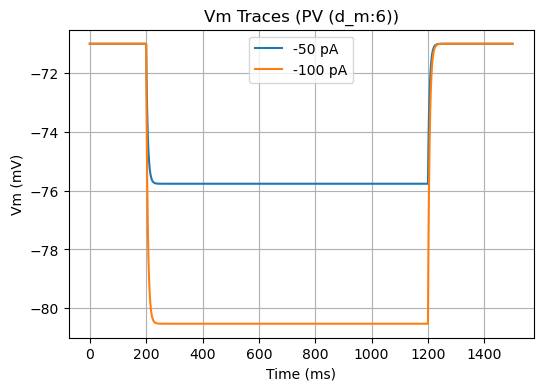

(<matplotlib.legend.Legend at 0x7f87ff732400>, None, None)

In [7]:
# Simulation parameters
sim_params = {
    'stim_amp': -0.1,
    'stim_delay': 200,
    'stim_dur': 1000,
    'h_tstop': 1500,
    'h_dt': 0.025
    }
# Currents injected for each sim
# sim_amps = [0,-25,-50,-75,-100]
sim_amps = [-50,-100]

cell = build_cell.simple_build_cell(soma_diam_multiplier)
looped_records = run_sim.looped_current_injection(cell,sim_params,sim_amps)

# Analyze and plot each run
plt.figure(figsize=(6,4))
for amp in sim_amps:
    print(f"{amp} pA spike frequency = {looped_records['F'][amp]:.2f} Hz")
    if amp <0:
        # print('Desired Properties:       R_in=98.9, tau1=5.9, tau2=??.?, sag_ratio=0.960, V_rest=-71.25')
        print(f"{ACTPassiveModule.compute_gpp(looped_records['V'][amp], h.dt, sim_params['stim_delay'], sim_params['stim_delay']+sim_params['stim_dur']-100, amp/1000)}\n")
    plt.plot(looped_records['T'][amp], looped_records['V'][amp], label=f"{amp} pA")
    
# Plot parameters
plt.xlabel("Time (ms)"), plt.ylabel("Vm (mV)"), plt.title(f"Vm Traces ({cell_name} (d_m:{soma_diam_multiplier}))")
# plt.xlim(45,50)
# plt.ylim(-97,-55)
plt.legend(),plt.grid(),plt.show()


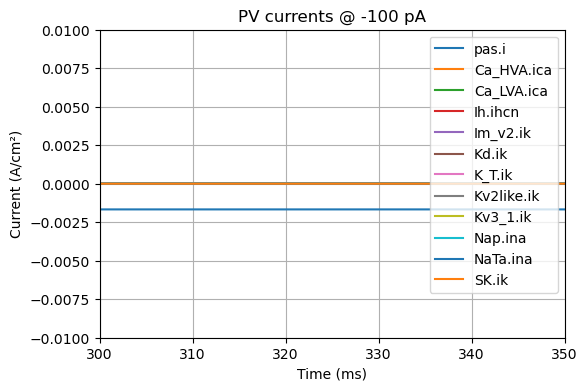

In [8]:
ampsel = sim_amps[-1]
currents = [
                    # 'pas.i', 
                    # # 'cadyn.i', 
                    # 'Ca_HVA.ica',
                    # 'Ca_LVA.ica',
                    # 'Ih.ihcn',
                    # 'Im_v2.ik', 
                    # 'Kd.ik',
                    # # 'K_T.ik',
                    # 'Kv2like.ik',
                    # 'Kv3_1.ik',
                    # 'Nap.ina',
                    # 'NaTa.ina',
                    # 'SK.ik',
                    ]
window = (300,350) #(1322,1325)

run_sim.plot_looped_currents(cell_name,ampsel,currents,looped_records,window)


# Tuning Active Properties

### 2. Multi-Sim Plot

40 pA spike frequency = 0.00 Hz


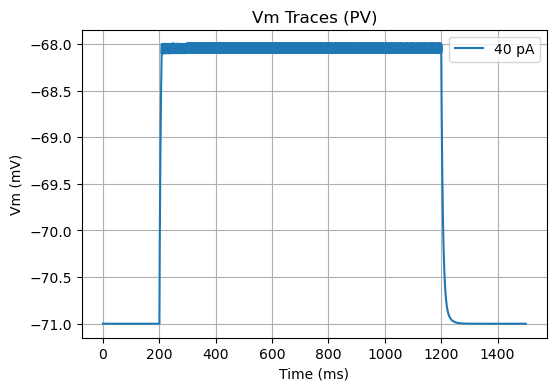

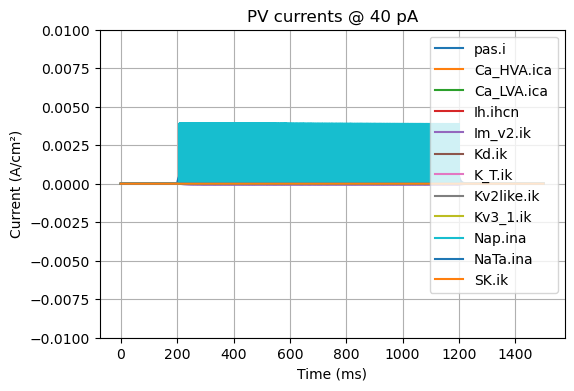

In [9]:
# Simulation parameters
sim_params = {
    'stim_amp': -0.1,
    'stim_delay': 200,
    'stim_dur': 1000,
    'h_tstop': 1500,
    'h_dt': 0.025
    }
# Currents injected for each sim
sim_amps = [40]

cell = build_cell.simple_build_cell(soma_diam_multiplier)
looped_records = run_sim.looped_current_injection(cell,sim_params,sim_amps)

# Analyze and plot each run
plt.figure(figsize=(6,4))
for amp in sim_amps:
    print(f"{amp} pA spike frequency = {looped_records['F'][amp]:.2f} Hz")
    if amp <0:
        print(f"{ACTPassiveModule.compute_gpp(looped_records['V'][amp], h.dt, sim_params['stim_delay'], sim_params['stim_delay']+sim_params['stim_dur']-10, amp/1000)}\n")
    plt.plot(looped_records['T'][amp], looped_records['V'][amp], label=f"{amp} pA")
    
# Plot parameters
plt.xlabel("Time (ms)"), plt.ylabel("Vm (mV)"), plt.title(f"Vm Traces ({cell_name})")
window = (None,None)
plt.xlim(window[0],window[1])
# plt.ylim(-68.2,-67.8)
plt.legend(),plt.grid(),plt.show()


ampsel = sim_amps[-1]
currents = [] # add specific currents to list
run_sim.plot_looped_currents(cell_name,ampsel,currents,looped_records,window)

### 3. Generate FI Curve

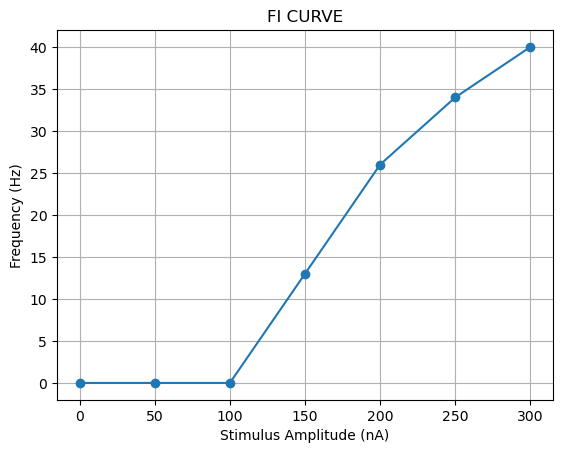

In [12]:
#set simulation parameters
sim_params = {
    'stim_amp': -0.1,
    'stim_delay': 200,
    'stim_dur': 1000,
    'h_tstop': 1500,
    'h_dt': 0.025
    }

#test the cell at multiple currents to get an FI curve
amp_range = (0, 300, 50) # (start, end, step)
amps = list(np.arange(amp_range[0], amp_range[1] + amp_range[2]/2, amp_range[2]))

cell = build_cell.simple_build_cell(soma_diam_multiplier)
freq_recs = run_sim.run_FI(cell,sim_params,amps)

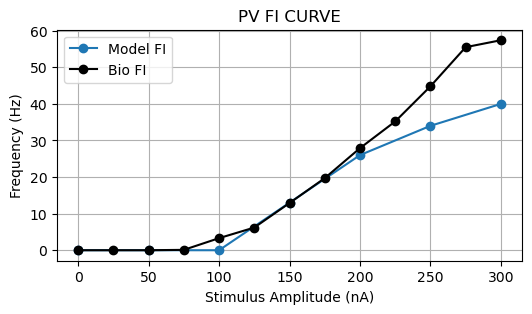

In [14]:
amps = [amp for amp in amps]
freqs = [freq_recs[amp] for amp in freq_recs]
bio_FI_data = {
    'SST': [(00,0),(25,1),(50,5.1),(75,9.5),(100,15.7),(125,23.9),(150,33),(175,41.7),(200,48.5),(225,54.2),(250,59.1),(275,64.6),(300,67.2)],
    'PV': [(00,0),(25,0),(50,0),(75,0.1),(100,3.3),(125,6.2),(150,12.9),(175,19.7),(200,27.9),(225,35.2),(250,44.8),(275,55.5),(300,57.4)]
}
if bio_FI_data[cell_name]:
    bio_FI = bio_FI_data[cell_name]
    bio_amps = []
    bio_freqs = []

    for FI in bio_FI:
        bio_amps.append(FI[0])
        bio_freqs.append(FI[1])


    plt.figure(figsize=(6,3))
    plt.plot(amps, freqs, marker='o', color = None,label = 'Model FI')
    plt.plot(bio_amps,bio_freqs,marker = 'o', color = 'k', label = 'Bio FI' )
    plt.title(f"{cell_name} FI CURVE")
    plt.xlabel("Stimulus Amplitude (nA)"),plt.ylabel("Frequency (Hz)")
    plt.legend(),plt.grid(),plt.show()